
========== DOWNLOADING DATASET ==========
Original Dataset Records: 1048555

========== DATASET ==========
   target                                                 id  date  flag  \
0       0  @switchfoot http://twitpic.com/2y1zl - Awww, t...   NaN   NaN   
1       0  is upset that he can't update his Facebook by ...   NaN   NaN   
2       0  @Kenichan I dived many times for the ball. Man...   NaN   NaN   
3       0    my whole body feels itchy and like its on fire    NaN   NaN   
4       0  @nationwideclass no, it's not behaving at all....   NaN   NaN   

   user  text  
0   NaN   NaN  
1   NaN   NaN  
2   NaN   NaN  
3   NaN   NaN  
4   NaN   NaN  

Columns: ['target', 'id', 'date', 'flag', 'user', 'text']

========== USING 50% DATASET ==========
50% Dataset Records: 524278
Expected: 800000

========== TOKENIZATION ==========
Fitting tokenizer...
Converting text to sequences...
Padding sequences...

Input Shape: (524278, 100)
Label Shape: (524278,)

========== TRAIN TEST SPLIT ====

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 646,273 (2.47 MB)

 Trainable params: 646,273 (2.47 MB)

 Non-trainable params: 0 (0.00 B)


========== TRAINING 50 EPOCHS ==========
Epoch 1/50
2950/2950 ━━━━━━━━━━━━━━━━━━━━ 56s 18ms/step - accuracy: 0.7624 - loss: 0.5488 - val_accuracy: 0.7671 - val_loss: 0.5434
Epoch 2/50
2950/2950 ━━━━━━━━━━━━━━━━━━━━ 51s 17ms/step - accuracy: 0.7626 - loss: 0.5484 - val_accuracy: 0.7671 - val_loss: 0.5427
Epoch 3/50
2950/2950 ━━━━━━━━━━━━━━━━━━━━ 53s 18ms/step - accuracy: 0.7626 - loss: 0.5482 - val_accuracy: 0.7671 - val_loss: 0.5431
Epoch 4/50
2950/2950 ━━━━━━━━━━━━━━━━━━━━ 81s 18ms/step - accuracy: 0.7626 - loss: 0.5483 - val_accuracy: 0.7671 - val_loss: 0.5431
Epoch 5/50
2950/2950 ━━━━━━━━━━━━━━━━━━━━ 50s 17ms/step - accuracy: 0.7626 - loss: 0.5485 - val_accuracy: 0.7671 - val_loss: 0.5430
Epoch 6/50
2950/2950 ━━━━━━━━━━━━━━━━━━━━ 51s 17ms/step - accuracy: 0.7626 - loss: 0.5485 - val_accuracy: 0.7671 - val_loss: 0.5427
Epoch 7/50
2950/2950 ━━━━━━━━━━━━━━━━━━━━ 50s 17ms/step - accuracy: 0.7626 - loss: 0.5484 - val_accuracy: 0.7671 - val_loss: 0.5430
Epoch 8/50
2950/2950 ━━━━━━━━━━━━━

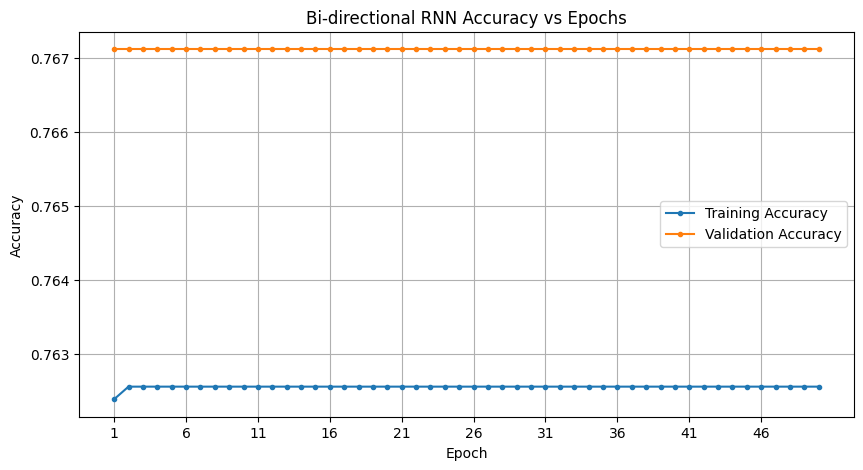

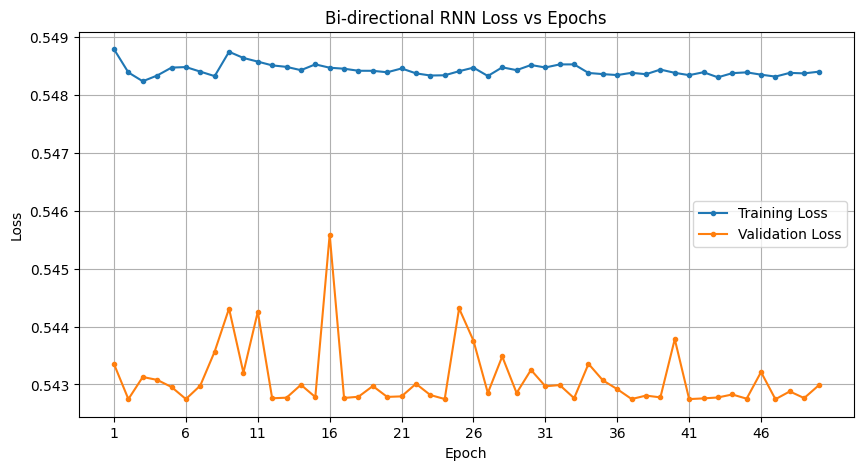


========== USER SENTENCE PREDICTION ==========
Enter a sentence for sentiment prediction: i love my india

========== USER SENTENCE RESULT ==========
Sentence: i love my india
Token Sequence: [1, 1, 1, 1]
Padded Sequence: [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Probability: 0.2416
Sentiment: Negative


In [ ]:
# Set B - Q1. Create a Bi-directional RNN model to perform sentiment analysis and predict the sentiment for a given user sentence and also compute the model accuracy and model loss with respect to the number of epochs.

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


url = "https://raw.githubusercontent.com/NiteshKedia/Sentiment-Analysis/master/Word%20list%20with%20sentiment/trainingandtestdata/training.1600000.processed.noemoticon.csv"


print("\n========== DOWNLOADING DATASET ==========")

columns = [
    "target",
    "id",
    "date",
    "flag",
    "user",
    "text"
]

df = pd.read_csv(
    url,
    encoding="latin-1",
    header=None,
    names=columns
)

print(
    "Original Dataset Records:",
    len(df)
)


print("\n========== DATASET ==========")

print(
    df.head()
)

print(
    "\nColumns:",
    df.columns.tolist()
)




df["target"] = df["target"].replace({
    4: 1
})



print(
    "\n========== USING 50% DATASET =========="
)

df_50 = df.sample(
    frac=0.50,
    random_state=42
).reset_index(
    drop=True
)

print(
    "50% Dataset Records:",
    len(df_50)
)

print(
    "Expected:",
    800000
)



texts = df_50["text"].astype(
    str
).values

labels = df_50["target"].astype(
    "int32"
).values



print(
    "\n========== TOKENIZATION =========="
)

vocab = 10000
maxlen = 100

tokenizer = Tokenizer(
    num_words=vocab,
    oov_token="<OOV>"
)

print(
    "Fitting tokenizer..."
)

tokenizer.fit_on_texts(
    texts
)

print(
    "Converting text to sequences..."
)

sequences = tokenizer.texts_to_sequences(
    texts
)

print(
    "Padding sequences..."
)

x = pad_sequences(
    sequences,
    maxlen=maxlen,
    padding="post",
    truncating="post"
)

y = np.array(
    labels
)


print(
    "\nInput Shape:",
    x.shape
)

print(
    "Label Shape:",
    y.shape
)



print(
    "\n========== TRAIN TEST SPLIT =========="
)

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(
    "Training Samples:",
    len(x_train)
)

print(
    "Testing Samples:",
    len(x_test)
)



print(
    "\n========== MODEL CREATION =========="
)

bi_rnn = models.Sequential([

    layers.Input(
        shape=(maxlen,)
    ),

    layers.Embedding(
        input_dim=vocab,
        output_dim=64
    ),

    layers.Bidirectional(
        layers.SimpleRNN(
            32
        )
    ),

    layers.Dense(
        1,
        activation="sigmoid"
    )
])



bi_rnn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)



print(
    "\n========== MODEL SUMMARY =========="
)

bi_rnn.summary()



print(
    "\n========== TRAINING 50 EPOCHS =========="
)

hist_bi = bi_rnn.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=128,
    validation_split=0.10,
    verbose=1
)



print(
    "\n========== TEST EVALUATION =========="
)

test_loss, test_accuracy = bi_rnn.evaluate(
    x_test,
    y_test,
    verbose=0
)



print(
    "\n========== FINAL TEST RESULTS =========="
)

print(
    "BiRNN Accuracy:",
    round(
        test_accuracy * 100,
        2
    ),
    "%"
)

print(
    "BiRNN Loss:",
    round(
        test_loss,
        4
    )
)



print(
    "\n========== LAST EPOCH RESULTS =========="
)

print(
    "Training Loss:",
    round(
        hist_bi.history["loss"][-1],
        6
    )
)

print(
    "Training Accuracy:",
    round(
        hist_bi.history["accuracy"][-1] * 100,
        2
    ),
    "%"
)

print(
    "Validation Loss:",
    round(
        hist_bi.history["val_loss"][-1],
        6
    )
)

print(
    "Validation Accuracy:",
    round(
        hist_bi.history["val_accuracy"][-1] * 100,
        2
    ),
    "%"
)



print(
    "\n========== EPOCH-WISE RESULTS =========="
)

for i in range(50):

    print(
        f"Epoch {i + 1:02d}/50 | "
        f"Loss: {hist_bi.history['loss'][i]:.6f} | "
        f"Accuracy: {hist_bi.history['accuracy'][i]:.6f} | "
        f"Val Loss: {hist_bi.history['val_loss'][i]:.6f} | "
        f"Val Accuracy: {hist_bi.history['val_accuracy'][i]:.6f}"
    )



plt.figure(
    figsize=(10, 5)
)

plt.plot(
    range(1, 51),
    hist_bi.history["accuracy"],
    marker="o",
    markersize=3,
    label="Training Accuracy"
)

plt.plot(
    range(1, 51),
    hist_bi.history["val_accuracy"],
    marker="o",
    markersize=3,
    label="Validation Accuracy"
)

plt.title(
    "Bi-directional RNN Accuracy vs Epochs"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.xticks(
    range(1, 51, 5)
)

plt.legend()

plt.grid(True)

plt.show()



plt.figure(
    figsize=(10, 5)
)

plt.plot(
    range(1, 51),
    hist_bi.history["loss"],
    marker="o",
    markersize=3,
    label="Training Loss"
)

plt.plot(
    range(1, 51),
    hist_bi.history["val_loss"],
    marker="o",
    markersize=3,
    label="Validation Loss"
)

plt.title(
    "Bi-directional RNN Loss vs Epochs"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.xticks(
    range(1, 51, 5)
)

plt.legend()

plt.grid(True)

plt.show()



def predict_sentiment(sentence):


    sequence = tokenizer.texts_to_sequences(
        [sentence]
    )



    padded_sequence = pad_sequences(
        sequence,
        maxlen=maxlen,
        padding="post",
        truncating="post"
    )



    prediction = bi_rnn.predict(
        padded_sequence,
        verbose=0
    )[0][0]

    prediction = float(
        prediction
    )



    if prediction >= 0.5:

        sentiment = "Positive"

    else:

        sentiment = "Negative"



    print(
        "\n========== USER SENTENCE RESULT =========="
    )

    print(
        "Sentence:",
        sentence
    )

    print(
        "Token Sequence:",
        sequence[0]
    )

    print(
        "Padded Sequence:",
        padded_sequence[0].tolist()
    )

    print(
        "Probability:",
        round(
            prediction,
            4
        )
    )

    print(
        "Sentiment:",
        sentiment
    )



print(
    "\n========== USER SENTENCE PREDICTION =========="
)

user_sentence = input(
    "Enter a sentence for sentiment prediction: "
)

predict_sentiment(
    user_sentence
)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Data Shape: (60000, 28, 28)
Testing Data Shape : (10000, 28, 28)

========== MODEL SUMMARY ==========


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        20,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,386 (83.54 KB)

 Trainable params: 21,386 (83.54 KB)

 Non-trainable params: 0 (0.00 B)


========== TRAINING ==========

Epoch 1/20 | Loss: 0.437531 | Accuracy: 0.868983
W1 Shape: (28, 128) Mean: -0.001230 Min: -0.290928 Max: 0.305539 Std: 0.117485
W2 Shape: (128, 128) Mean: 0.000811 Min: -0.358726 Max: 0.389256 Std: 0.095318
W3 Shape: (128,) Mean: 0.001358 Min: -0.057945 Max: 0.049783 Std: 0.020231
W4 Shape: (128, 10) Mean: 0.002201 Min: -0.357464 Max: 0.348877 Std: 0.153045
W5 Shape: (10,) Mean: 0.000516 Min: -0.091106 Max: 0.057045 Std: 0.038801

Epoch 2/20 | Loss: 0.195541 | Accuracy: 0.943667
W1 Mean: -0.002059 Min: -0.320771 Max: 0.334896 MeanChange: -0.000829 MaxChange: 0.065943
W2 Mean: 0.001059 Min: -0.377584 Max: 0.395960 MeanChange: 0.000249 MaxChange: 0.061465
W3 Mean: 0.002279 Min: -0.060020 Max: 0.065036 MeanChange: 0.000921 MaxChange: 0.015927
W4 Mean: 0.002274 Min: -0.383248 Max: 0.392823 MeanChange: 0.000073 MaxChange: 0.085412
W5 Mean: -0.000601 Min: -0.134404 Max: 0.077637 MeanChange: -0.001117 MaxChange: 0.043298

Epoch 3/20 | Loss: 0.156310 | Accuracy

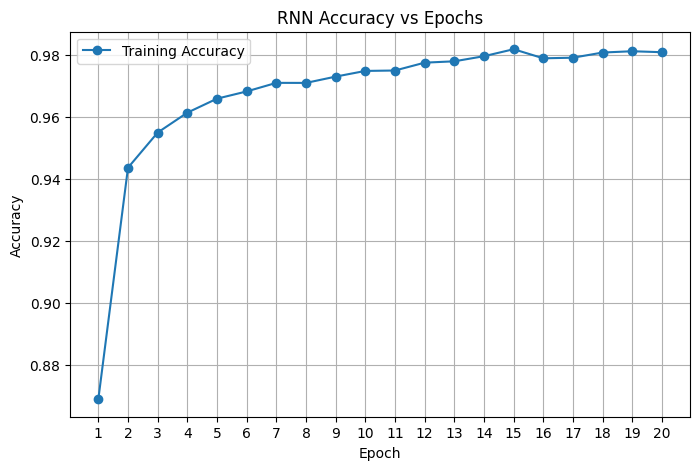

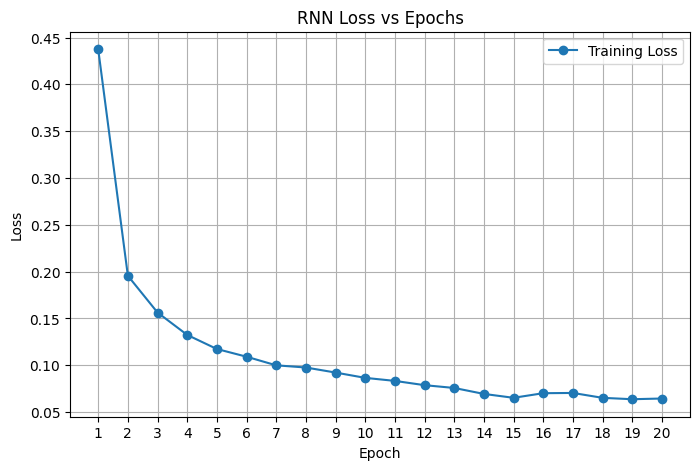

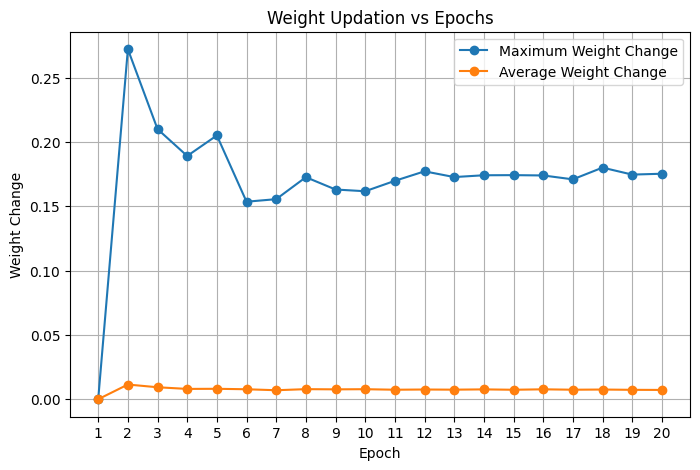


========== SAMPLE PREDICTIONS ==========
Image 1: Actual = 7, Predicted = 7
Image 2: Actual = 2, Predicted = 2
Image 3: Actual = 1, Predicted = 1
Image 4: Actual = 0, Predicted = 0
Image 5: Actual = 4, Predicted = 4


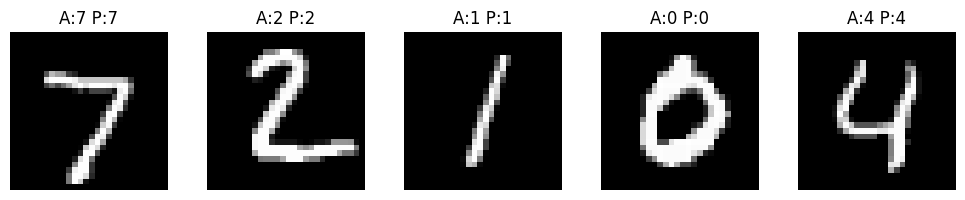

In [ ]:
# Set B - Q2. Write a python program to recognize handwritten digits using RNN.

import numpy as np
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt



(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Training Data Shape:", x_train.shape)
print("Testing Data Shape :", x_test.shape)



rnn_digit = models.Sequential([

    layers.Input(shape=(28, 28)),

    layers.SimpleRNN(
        128,
        activation="tanh"
    ),

    layers.Dense(
        10,
        activation="softmax"
    )
])



rnn_digit.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)



class WeightUpdate(tf.keras.callbacks.Callback):

    def on_train_begin(self, logs=None):

        self.old_weights = None
        self.epoch_numbers = []
        self.weight_changes = []
        self.mean_changes = []


    def on_epoch_end(self, epoch, logs=None):

        new_weights = self.model.get_weights()

        total_max_change = 0
        total_mean_change = 0
        weight_count = 0

        print(
            f"\nEpoch {epoch + 1}/20"
            f" | Loss: {logs['loss']:.6f}"
            f" | Accuracy: {logs['accuracy']:.6f}"
        )


        if self.old_weights is None:

            for i, w in enumerate(new_weights):

                print(
                    f"W{i + 1} "
                    f"Shape: {w.shape} "
                    f"Mean: {np.mean(w):.6f} "
                    f"Min: {np.min(w):.6f} "
                    f"Max: {np.max(w):.6f} "
                    f"Std: {np.std(w):.6f}"
                )

            self.weight_changes.append(0)
            self.mean_changes.append(0)


        else:

            for i, w in enumerate(new_weights):

                d = w - self.old_weights[i]

                mean_change = np.mean(
                    np.abs(d)
                )

                max_change = np.max(
                    np.abs(d)
                )

                print(
                    f"W{i + 1} "
                    f"Mean: {np.mean(w):.6f} "
                    f"Min: {np.min(w):.6f} "
                    f"Max: {np.max(w):.6f} "
                    f"MeanChange: {np.mean(d):.6f} "
                    f"MaxChange: {max_change:.6f}"
                )

                total_max_change += max_change
                total_mean_change += mean_change
                weight_count += 1


            self.weight_changes.append(
                total_max_change
            )

            self.mean_changes.append(
                total_mean_change / weight_count
            )


        self.epoch_numbers.append(
            epoch + 1
        )

        self.old_weights = [
            w.copy()
            for w in new_weights
        ]


weight_callback = WeightUpdate()



print("\n========== MODEL SUMMARY ==========")

rnn_digit.summary()



print("\n========== TRAINING ==========")

history = rnn_digit.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=128,
    verbose=0,
    callbacks=[weight_callback]
)



loss, acc = rnn_digit.evaluate(
    x_test,
    y_test,
    verbose=0
)


print("\n========== FINAL RESULTS ==========")

print(
    "RNN Digit Accuracy:",
    round(acc * 100, 2),
    "%"
)

print(
    "RNN Digit Loss:",
    round(loss, 4)
)



plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 21),
    history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.title(
    "RNN Accuracy vs Epochs"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.xticks(range(1, 21))

plt.legend()
plt.grid(True)

plt.show()



plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 21),
    history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.title(
    "RNN Loss vs Epochs"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.xticks(range(1, 21))

plt.legend()
plt.grid(True)

plt.show()



plt.figure(figsize=(8, 5))

plt.plot(
    weight_callback.epoch_numbers,
    weight_callback.weight_changes,
    marker="o",
    label="Maximum Weight Change"
)

plt.plot(
    weight_callback.epoch_numbers,
    weight_callback.mean_changes,
    marker="o",
    label="Average Weight Change"
)

plt.title(
    "Weight Updation vs Epochs"
)

plt.xlabel("Epoch")
plt.ylabel("Weight Change")

plt.xticks(range(1, 21))

plt.legend()
plt.grid(True)

plt.show()



pred = rnn_digit.predict(
    x_test[:5],
    verbose=0
)


print("\n========== SAMPLE PREDICTIONS ==========")

for i in range(5):

    predicted_digit = np.argmax(
        pred[i]
    )

    print(
        f"Image {i + 1}: "
        f"Actual = {y_test[i]}, "
        f"Predicted = {predicted_digit}"
    )



fig, axes = plt.subplots(
    1,
    5,
    figsize=(10, 2)
)


for i, ax in enumerate(axes):

    ax.imshow(
        x_test[i],
        cmap="gray"
    )

    ax.set_title(
        f"A:{y_test[i]} P:{pred[i].argmax()}"
    )

    ax.axis("off")


plt.tight_layout()
plt.show()

In [ ]:
# Q1. Create a simple RNN model for generating data using text and predict the text using a pre-trained model. (Use ReLU and Softmax activation function). (Use shakespeare.txt file.)
# Dataset/File: Download or add the shakespeare.txt file before running this code.
from google.colab import files

uploaded = files.upload()

file_path = "shakespeare.txt"

Saving shakespeare.txt to shakespeare.txt


In [ ]:
# Q1. Create a simple RNN model for generating data using text and predict the text using a pre-trained model. (Use ReLU and Softmax activation function). (Use shakespeare.txt file.)
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense


FILE_NAME = "shakespeare.txt"

with open(FILE_NAME, "r", encoding="utf-8") as file:
    text = file.read()

print("========== DATA INFORMATION ==========")
print("Total characters:", len(text))
print("\nFirst 300 characters:")
print(text[:300])

if len(text) < 100:
    raise ValueError("shakespeare.txt is too small or empty.")


chars = sorted(set(text))

char_to_int = {char: i for i, char in enumerate(chars)}
int_to_char = {i: char for i, char in enumerate(chars)}

vocab_size = len(chars)

print("\nVocabulary size:", vocab_size)


sequence_length = 40

X = []
y = []

for i in range(len(text) - sequence_length):

    input_sequence = text[i:i + sequence_length]

    target_character = text[i + sequence_length]

    X.append([
        char_to_int[character]
        for character in input_sequence
    ])

    y.append(char_to_int[target_character])

X = np.array(X)
y = np.array(y)

print("\n========== SEQUENCE INFORMATION ==========")
print("X shape:", X.shape)
print("y shape:", y.shape)


model = Sequential([

    Embedding(
        input_dim=vocab_size,
        output_dim=64
    ),

    SimpleRNN(
        128,
        activation="relu"
    ),

    Dense(
        vocab_size,
        activation="softmax"
    )
])


model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\n========== MODEL ==========")
model.summary()


print("\n========== TRAINING ==========")

history = model.fit(
    X,
    y,
    epochs=20,
    batch_size=128,
    validation_split=0.1
)


def predict_next_character(input_text):

    if len(input_text) < sequence_length:
        input_text = input_text.rjust(sequence_length)

    else:
        input_text = input_text[-sequence_length:]

    input_numbers = [
        char_to_int.get(character, 0)
        for character in input_text
    ]

    input_array = np.array([input_numbers])

    probabilities = model.predict(
        input_array,
        verbose=0
    )[0]

    predicted_index = np.argmax(probabilities)

    predicted_character = int_to_char[predicted_index]

    confidence = probabilities[predicted_index]

    return input_text, predicted_character, confidence



print("\n========== NEXT CHARACTER PREDICTION ==========")

user_input = input(
    "Enter a sequence for next-character prediction: "
)

input_text, predicted_character, confidence = \
    predict_next_character(user_input)

print("\nInput Sequence:")
print(repr(input_text))

print("\nPredicted Next Character:")
print(repr(predicted_character))

print("\nConfidence:")
print(round(float(confidence), 4))



def generate_text(start_text, number_of_characters=200):

    generated_text = start_text

    for _ in range(number_of_characters):

        current_sequence = generated_text[-sequence_length:]

        if len(current_sequence) < sequence_length:
            current_sequence = current_sequence.rjust(
                sequence_length
            )

        input_numbers = [
            char_to_int.get(character, 0)
            for character in current_sequence
        ]

        input_array = np.array([input_numbers])

        probabilities = model.predict(
            input_array,
            verbose=0
        )[0]

        predicted_index = np.argmax(probabilities)

        predicted_character = int_to_char[predicted_index]

        generated_text += predicted_character

    return generated_text



print("\n========== TEXT GENERATION ==========")

starting_text = input(
    "Enter starting text: "
)

result = generate_text(
    starting_text,
    number_of_characters=200
)

print("\nGenerated Text:")
print(result)



print("\n========== ACTUAL VS PREDICTED ==========")

test_position = 1000

test_sequence = text[
    test_position:test_position + sequence_length
]

actual_next_character = text[
    test_position + sequence_length
]

test_numbers = [
    char_to_int[character]
    for character in test_sequence
]

test_array = np.array([test_numbers])

probabilities = model.predict(
    test_array,
    verbose=0
)[0]

predicted_index = np.argmax(probabilities)

predicted_next_character = int_to_char[
    predicted_index
]

confidence = probabilities[predicted_index]

print("Input Sequence:")
print(repr(test_sequence))

print("\nActual Next Character:")
print(repr(actual_next_character))

print("\nPredicted Next Character:")
print(repr(predicted_next_character))

print("\nConfidence:")
print(round(float(confidence), 4))


========== DATA INFORMATION ==========
Total characters: 30128

First 300 characters:
# 1) Sentiment Analysis using Simple RNN

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

print("       SENTIMENT ANALYSIS USING SIMPLE RNN")
print("                  IMDB DATASET")



print("\nStep 1: Loading IMDB dataset...")

vocab_size = 10000

(x_train, y_train), (x_

Vocabulary size: 84

========== SEQUENCE INFORMATION ==========
X shape: (30088, 40)
y shape: (30088,)

========== MODEL ==========


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


========== TRAINING ==========
Epoch 1/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.2689 - loss: 3.0404 - val_accuracy: 0.5244 - val_loss: 1.9292
Epoch 2/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4904 - loss: 2.0140 - val_accuracy: 0.6431 - val_loss: 1.3687
Epoch 3/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6257 - loss: 1.4683 - val_accuracy: 0.7365 - val_loss: 1.0923
Epoch 4/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7127 - loss: 1.1373 - val_accuracy: 0.7723 - val_loss: 0.9471
Epoch 5/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7676 - loss: 0.9295 - val_accuracy: 0.7969 - val_loss: 0.8879
Epoch 6/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8048 - loss: 0.7903 - val_accuracy: 0.8102 - val_loss: 0.8336
Epoch 7/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8347 - loss: 0.6818 - val_accuracy: 0.8259 - val_loss: 0.7877
Epoch 8/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8546

       TIME SERIES FORECASTING USING LSTM
          MONTHLY MILK PRODUCTION

STEP 1: DOWNLOADING DATASET FROM INTERNET
----------------------------------------------------------------------
Dataset downloaded successfully!

First 5 records:
     Month  Monthly milk production (pounds per cow)
0  1962-01                                       589
1  1962-02                                       561
2  1962-03                                       640
3  1962-04                                       656
4  1962-05                                       727

Dataset shape:
(168, 2)

Column names:
['Month', 'Monthly milk production (pounds per cow)']

STEP 2: SELECTING DATE AND MILK PRODUCTION
----------------------------------------------------------------------
Date column       : Month
Production column : Monthly milk production (pounds per cow)

Number of records: 168

Starting month:
1962-01-01 00:00:00

Ending month:
1975-12-01 00:00:00

STEP 3: DATA EXPLORATION
-----------------------

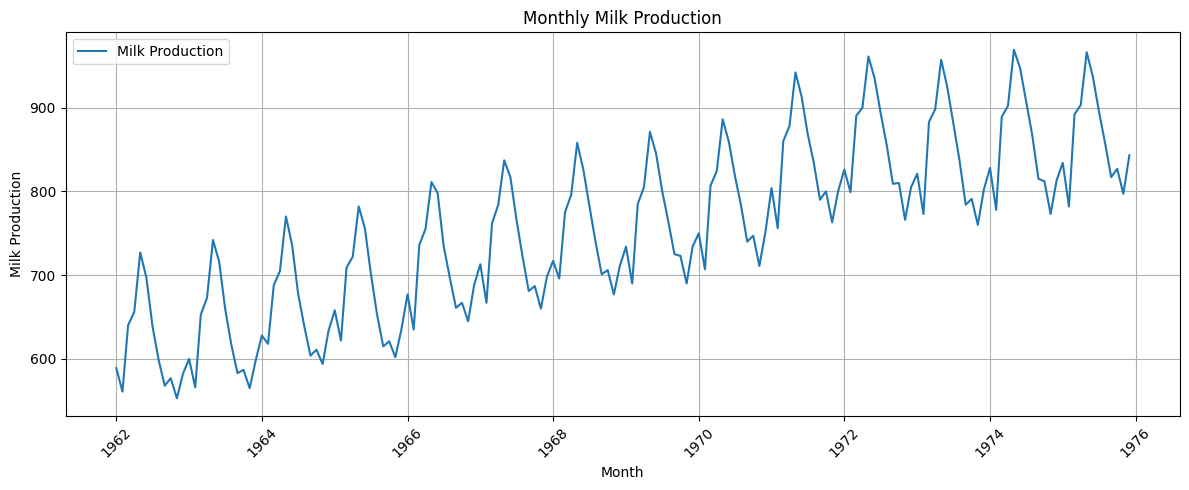


STEP 5: NORMALIZING DATA
----------------------------------------------------------------------
Minimum production : 553.0
Maximum production : 969.0

First 10 normalized values:
[0.08653846 0.01923077 0.20913461 0.24759616 0.41826922 0.34615386
 0.20913461 0.11057692 0.03605769 0.05769231]

Data normalized between 0 and 1.

STEP 6: CREATING TIME SERIES SEQUENCES
----------------------------------------------------------------------
Input shape before reshaping: (156, 12)
Target shape: (156,)

Time steps: 12
Meaning: previous 12 months are used to predict the next month.

STEP 7: RESHAPING DATA FOR LSTM
----------------------------------------------------------------------
LSTM input shape: (156, 12, 1)

Expected format:
(samples, time steps, features)

STEP 8: SPLITTING DATA
----------------------------------------------------------------------
Total samples     : 156
Training samples  : 124
Testing samples   : 32

Training percentage: 80%
Testing percentage : 20%

STEP 9: CREATING L

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)


STEP 11: COMPILING MODEL
----------------------------------------------------------------------
Optimizer : Adam
Loss      : Mean Squared Error
Model compiled successfully.

STEP 12: TRAINING LSTM MODEL
----------------------------------------------------------------------
Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - loss: 0.2593 - val_loss: 0.3514
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0968 - val_loss: 0.0761
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0337 - val_loss: 0.0378
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0360 - val_loss: 0.0282
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0272 - val_loss: 0.0409
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0288 - val_loss: 0.0374
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0271 - val_loss: 0.0282
Epoch 8/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0266 - val_loss: 0.0280
Epoch 9/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0

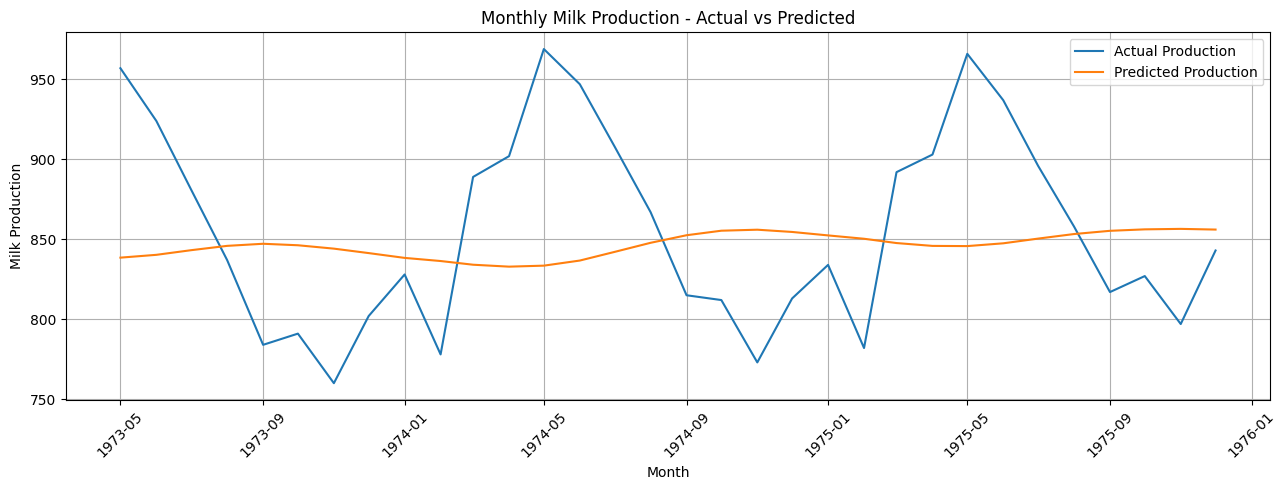


STEP 20: TRAINING AND VALIDATION LOSS
----------------------------------------------------------------------


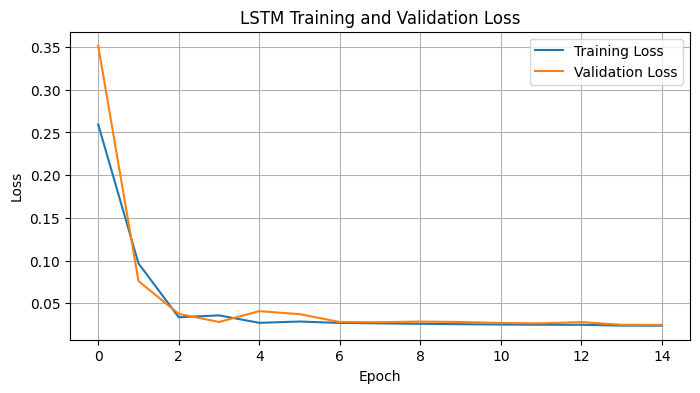


STEP 21: PREDICTING NEXT 12 MONTHS

STEP 22: CONVERTING FUTURE PREDICTIONS
----------------------------------------------------------------------
Future predictions converted successfully.

STEP 23: NEXT 12 MONTHS FORECAST
----------------------------------------------------------------------

Next 12 months predicted production:

     Month Predicted Milk Production
1976-01-01                    855.65
1976-02-01                    855.22
1976-03-01                    857.42
1976-04-01                    854.63
1976-05-01                    851.52
1976-06-01                    845.72
1976-07-01                    841.44
1976-08-01                    839.08
1976-09-01                    838.39
1976-10-01                    839.45
1976-11-01                    839.93
1976-12-01                    841.68

STEP 24: SAVING FUTURE FORECAST
----------------------------------------------------------------------
Future forecast saved successfully.
File: /content/future_milk_production_forecas

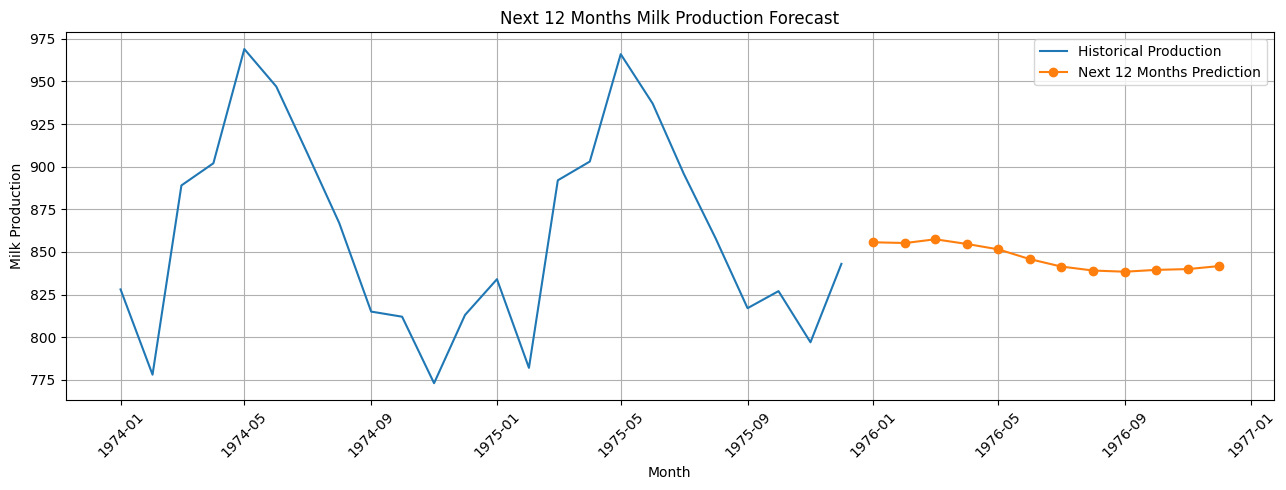


                  FINAL RESULT

Dataset:
  Total records : 168

Model:
  LSTM
  Time steps : 12
  LSTM units : 50
  Epochs     : 20
  Batch size : 16

Performance:
  RMSE: 65.5577
  MAE : 56.5146

Forecast:
  Next 12 months predicted successfully.

Files generated:
  1. /content/monthly_milk_predictions.csv
  2. /content/future_milk_production_forecast.csv

       TIME SERIES FORECASTING COMPLETED


In [ ]:
# Q2. Write a python program to implement time series forecasting in Recurrent Neural network using LSTM module. (Use monthly_milk_production.csv.)
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

print("=" * 70)
print("       TIME SERIES FORECASTING USING LSTM")
print("          MONTHLY MILK PRODUCTION")
print("=" * 70)



print("\nSTEP 1: DOWNLOADING DATASET FROM INTERNET")
print("-" * 70)

url = "https://raw.githubusercontent.com/plotly/datasets/master/monthly-milk-production-pounds.csv"

data = pd.read_csv(url)

print("Dataset downloaded successfully!")

print("\nFirst 5 records:")
print(data.head())

print("\nDataset shape:")
print(data.shape)

print("\nColumn names:")
print(data.columns.tolist())



print("\nSTEP 2: SELECTING DATE AND MILK PRODUCTION")
print("-" * 70)

date_column = data.columns[0]
production_column = data.columns[1]

print("Date column       :", date_column)
print("Production column :", production_column)

data[date_column] = pd.to_datetime(
    data[date_column],
    errors="coerce"
)

data[production_column] = pd.to_numeric(
    data[production_column],
    errors="coerce"
)

data = data.dropna(
    subset=[date_column, production_column]
)

data = data.sort_values(
    date_column
).reset_index(drop=True)

dates = data[date_column].copy()

values = data[production_column].values.astype(
    "float32"
)

print("\nNumber of records:", len(values))

print("\nStarting month:")
print(dates.iloc[0])

print("\nEnding month:")
print(dates.iloc[-1])



print("\nSTEP 3: DATA EXPLORATION")
print("-" * 70)

print("\nFirst 5 records:")
print(data.head())

print("\nLast 5 records:")
print(data.tail())

print("\nDataset information:")
data.info()

print("\nStatistical description:")
print(data[production_column].describe())

print("\nMissing values:")
print(data.isnull().sum())



print("\nSTEP 4: VISUALIZING ORIGINAL MILK PRODUCTION")
print("-" * 70)

plt.figure(figsize=(12, 5))

plt.plot(
    dates,
    values,
    label="Milk Production"
)

plt.xlabel("Month")
plt.ylabel("Milk Production")
plt.title("Monthly Milk Production")

plt.legend()
plt.grid(True)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()



print("\nSTEP 5: NORMALIZING DATA")
print("-" * 70)

minimum = values.min()
maximum = values.max()

values_normalized = (
    (values - minimum)
    / (maximum - minimum)
)

print("Minimum production :", minimum)
print("Maximum production :", maximum)

print("\nFirst 10 normalized values:")

print(
    values_normalized[:10]
)

print("\nData normalized between 0 and 1.")



print("\nSTEP 6: CREATING TIME SERIES SEQUENCES")
print("-" * 70)


time_steps = 12

X = []
y = []
sequence_dates = []

for i in range(
    len(values_normalized) - time_steps
):

    X.append(
        values_normalized[
            i:i + time_steps
        ]
    )

    y.append(
        values_normalized[
            i + time_steps
        ]
    )

    sequence_dates.append(
        dates.iloc[
            i + time_steps
        ]
    )

X = np.array(X)
y = np.array(y)

sequence_dates = pd.Series(
    sequence_dates
).reset_index(drop=True)

print(
    "Input shape before reshaping:",
    X.shape
)

print(
    "Target shape:",
    y.shape
)

print(
    "\nTime steps:",
    time_steps
)

print(
    "Meaning: previous 12 months are used",
    "to predict the next month."
)



print("\nSTEP 7: RESHAPING DATA FOR LSTM")
print("-" * 70)

X = X.reshape(
    X.shape[0],
    X.shape[1],
    1
)

print(
    "LSTM input shape:",
    X.shape
)

print(
    "\nExpected format:"
)

print(
    "(samples, time steps, features)"
)



print("\nSTEP 8: SPLITTING DATA")
print("-" * 70)


train_size = int(
    len(X) * 0.80
)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

test_dates = sequence_dates.iloc[
    train_size:
].reset_index(drop=True)

print(
    "Total samples     :",
    len(X)
)

print(
    "Training samples  :",
    len(X_train)
)

print(
    "Testing samples   :",
    len(X_test)
)

print(
    "\nTraining percentage: 80%"
)

print(
    "Testing percentage : 20%"
)



print("\nSTEP 9: CREATING LSTM MODEL")
print("-" * 70)

model = tf.keras.Sequential([

    tf.keras.layers.Input(
        shape=(time_steps, 1)
    ),

    tf.keras.layers.LSTM(
        50
    ),

    tf.keras.layers.Dense(
        1
    )
])

print(
    "LSTM model created successfully."
)



print("\nSTEP 10: MODEL SUMMARY")
print("-" * 70)

model.summary()



print("\nSTEP 11: COMPILING MODEL")
print("-" * 70)

model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

print(
    "Optimizer : Adam"
)

print(
    "Loss      : Mean Squared Error"
)

print(
    "Model compiled successfully."
)



print("\nSTEP 12: TRAINING LSTM MODEL")
print("-" * 70)

history = model.fit(
    X_train,
    y_train,

    epochs=15,

    batch_size=16,

    validation_data=(
        X_test,
        y_test
    ),

    verbose=1
)

print(
    "\nLSTM training completed successfully."
)



print("\nSTEP 13: EVALUATING MODEL")
print("-" * 70)

test_loss = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(
    "Test Loss:",
    test_loss
)



print("\nSTEP 14: MAKING TEST PREDICTIONS")
print("-" * 70)

predicted_normalized = model.predict(
    X_test,
    verbose=0
)

predicted_normalized = (
    predicted_normalized.flatten()
)

print(
    "Predictions generated successfully."
)

print(
    "Number of predictions:",
    len(predicted_normalized)
)



print("\nSTEP 15: CONVERTING PREDICTIONS TO ORIGINAL SCALE")
print("-" * 70)

predicted = (
    predicted_normalized
    * (maximum - minimum)
    + minimum
)

actual = (
    y_test
    * (maximum - minimum)
    + minimum
)

print(
    "Predictions converted successfully."
)



print("\nSTEP 16: CALCULATING MODEL PERFORMANCE")
print("-" * 70)

rmse = np.sqrt(
    mean_squared_error(
        actual,
        predicted
    )
)

mae = mean_absolute_error(
    actual,
    predicted
)

print(
    "RMSE:",
    round(rmse, 4)
)

print(
    "MAE :",
    round(mae, 4)
)

print(
    "\nRMSE = Root Mean Squared Error"
)

print(
    "MAE  = Mean Absolute Error"
)



print("\nSTEP 17: MONTH-WISE PREDICTIONS")
print("-" * 70)

results = pd.DataFrame({

    "Month": test_dates,

    "Actual Production": actual,

    "Predicted Production": predicted

})

results["Difference"] = (
    results["Actual Production"]
    - results["Predicted Production"]
)

results["Percentage Error"] = (
    np.abs(
        results["Difference"]
    )
    /
    results["Actual Production"]
) * 100


print(
    "\nMONTH-WISE PREDICTIONS:\n"
)

print(
    results.to_string(
        index=False,

        formatters={

            "Actual Production":
                "{:.2f}".format,

            "Predicted Production":
                "{:.2f}".format,

            "Difference":
                "{:.2f}".format,

            "Percentage Error":
                "{:.2f}%".format
        }
    )
)



print("\nSTEP 18: SAVING MONTHLY PREDICTIONS")
print("-" * 70)

results.to_csv(
    "/content/monthly_milk_predictions.csv",
    index=False
)

print(
    "Prediction file saved successfully."
)

print(
    "File: /content/monthly_milk_predictions.csv"
)



print("\nSTEP 19: ACTUAL VS PREDICTED GRAPH")
print("-" * 70)

plt.figure(figsize=(13, 5))

plt.plot(
    test_dates,
    actual,
    label="Actual Production"
)

plt.plot(
    test_dates,
    predicted,
    label="Predicted Production"
)

plt.xlabel("Month")

plt.ylabel(
    "Milk Production"
)

plt.title(
    "Monthly Milk Production - Actual vs Predicted"
)

plt.legend()

plt.grid(True)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()



print("\nSTEP 20: TRAINING AND VALIDATION LOSS")
print("-" * 70)

plt.figure(figsize=(8, 4))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "LSTM Training and Validation Loss"
)

plt.legend()

plt.grid(True)

plt.show()



print("\n" + "=" * 70)
print("STEP 21: PREDICTING NEXT 12 MONTHS")
print("=" * 70)

current_sequence = (
    values_normalized[-time_steps:].copy()
)

future_predictions_normalized = []

future_dates = []

last_date = dates.iloc[-1]


for i in range(12):

    input_sequence = (
        current_sequence.reshape(
            1,
            time_steps,
            1
        )
    )

    next_prediction = model.predict(
        input_sequence,
        verbose=0
    )[0][0]

    future_predictions_normalized.append(
        next_prediction
    )

    current_sequence = np.append(
        current_sequence[1:],
        next_prediction
    )

    next_month = (
        last_date
        + pd.DateOffset(
            months=i + 1
        )
    )

    future_dates.append(
        next_month
    )



print("\nSTEP 22: CONVERTING FUTURE PREDICTIONS")
print("-" * 70)

future_predictions = (
    np.array(
        future_predictions_normalized
    )
    * (maximum - minimum)
    + minimum
)

print(
    "Future predictions converted successfully."
)



print("\nSTEP 23: NEXT 12 MONTHS FORECAST")
print("-" * 70)

future_results = pd.DataFrame({

    "Month": future_dates,

    "Predicted Milk Production":
        future_predictions

})

print(
    "\nNext 12 months predicted production:\n"
)

print(
    future_results.to_string(
        index=False,

        formatters={
            "Predicted Milk Production":
                "{:.2f}".format
        }
    )
)



print("\nSTEP 24: SAVING FUTURE FORECAST")
print("-" * 70)

future_results.to_csv(
    "/content/future_milk_production_forecast.csv",
    index=False
)

print(
    "Future forecast saved successfully."
)

print(
    "File: /content/future_milk_production_forecast.csv"
)



print("\nSTEP 25: FUTURE 12 MONTH FORECAST GRAPH")
print("-" * 70)

plt.figure(figsize=(13, 5))

recent_dates = dates.iloc[-24:]

recent_values = values[-24:]


plt.plot(
    recent_dates,
    recent_values,
    label="Historical Production"
)


plt.plot(
    future_dates,
    future_predictions,
    marker="o",
    label="Next 12 Months Prediction"
)


plt.xlabel("Month")

plt.ylabel(
    "Milk Production"
)

plt.title(
    "Next 12 Months Milk Production Forecast"
)

plt.legend()

plt.grid(True)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()



print("\n" + "=" * 70)
print("                  FINAL RESULT")
print("=" * 70)

print("\nDataset:")
print("  Total records :", len(values))

print("\nModel:")
print("  LSTM")
print("  Time steps :", time_steps)
print("  LSTM units :", 50)
print("  Epochs     :", 20)
print("  Batch size :", 16)

print("\nPerformance:")
print(
    "  RMSE:",
    round(rmse, 4)
)

print(
    "  MAE :",
    round(mae, 4)
)

print("\nForecast:")
print(
    "  Next 12 months predicted successfully."
)

print("\nFiles generated:")

print(
    "  1. /content/monthly_milk_predictions.csv"
)

print(
    "  2. /content/future_milk_production_forecast.csv"
)

print("\n" + "=" * 70)
print("       TIME SERIES FORECASTING COMPLETED")
print("=" * 70)


========== DATASET ==========
         Date   AAPL.Open   AAPL.High    AAPL.Low  AAPL.Close  AAPL.Volume  \
0  2015-02-17  127.489998  128.880005  126.919998  127.830002     63152400   
1  2015-02-18  127.629997  128.779999  127.449997  128.720001     44891700   
2  2015-02-19  128.479996  129.029999  128.330002  128.449997     37362400   
3  2015-02-20  128.619995  129.500000  128.050003  129.500000     48948400   
4  2015-02-23  130.020004  133.000000  129.660004  133.000000     70974100   

   AAPL.Adjusted          dn        mavg          up   direction  
0     122.905254  106.741052  117.927667  129.114281  Increasing  
1     123.760965  107.842423  118.940333  130.038244  Increasing  
2     123.501363  108.894245  119.889167  130.884089  Decreasing  
3     124.510914  109.785449  120.763500  131.741551  Increasing  
4     127.876074  110.372516  121.720167  133.067817  Increasing  
Columns: ['Date', 'AAPL.Open', 'AAPL.High', 'AAPL.Low', 'AAPL.Close', 'AAPL.Volume', 'AAPL.Adjuste

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

...

 Total params: 81,301 (317.58 KB)

 Trainable params: 81,301 (317.58 KB)

 Non-trainable params: 0 (0.00 B)


========== BILSTM TRAINING ==========

Epoch 1/15 | Loss:0.073182
W1 Shape:(1, 200) Mean:0.006691 Min:-0.177984 Max:0.176671 Std:0.099132
W2 Shape:(50, 200) Mean:-0.000244 Min:-0.283243 Max:0.256783 Std:0.070888
W3 Shape:(200,) Mean:0.250720 Min:-0.008822 Max:1.006726 Std:0.432929
W4 Shape:(1, 200) Mean:-0.007871 Min:-0.180821 Max:0.177253 Std:0.095838
W5 Shape:(50, 200) Mean:0.000750 Min:-0.265856 Max:0.245614 Std:0.070915
W6 Shape:(200,) Mean:0.249188 Min:-0.008782 Max:1.008554 Std:0.432927
W7 Shape:(100, 200) Mean:-0.000221 Min:-0.150826 Max:0.150138 Std:0.082394
W8 Shape:(50, 200) Mean:0.001160 Min:-0.240596 Max:0.248435 Std:0.070847
W9 Shape:(200,) Mean:0.250320 Min:-0.010534 Max:1.008005 Std:0.432887
W10 Shape:(100, 200) Mean:0.000351 Min:-0.150764 Max:0.149427 Std:0.081473
W11 Shape:(50, 200) Mean:0.000080 Min:-0.258433 Max:0.267486 Std:0.070901
W12 Shape:(200,) Mean:0.249934 Min:-0.008604 Max:1.007791 Std:0.432828
W13 Shape:(100, 1) Mean:0.010052 Min:-0.241808 Max:0.229653 Std


========== EPOCH LOSS VALUES ==========
Epoch 01/15 | LSTM:0.074206 | GRU:0.073010 | RNN:0.018219 | BiLSTM:0.073182
Epoch 02/15 | LSTM:0.018763 | GRU:0.015005 | RNN:0.004932 | BiLSTM:0.017786
Epoch 03/15 | LSTM:0.011642 | GRU:0.008319 | RNN:0.003583 | BiLSTM:0.012892
Epoch 04/15 | LSTM:0.009545 | GRU:0.004908 | RNN:0.002985 | BiLSTM:0.009972
Epoch 05/15 | LSTM:0.007988 | GRU:0.003662 | RNN:0.002630 | BiLSTM:0.008268
Epoch 06/15 | LSTM:0.007380 | GRU:0.003132 | RNN:0.002532 | BiLSTM:0.007056
Epoch 07/15 | LSTM:0.007034 | GRU:0.003120 | RNN:0.002469 | BiLSTM:0.005979
Epoch 08/15 | LSTM:0.006560 | GRU:0.003031 | RNN:0.002213 | BiLSTM:0.004918
Epoch 09/15 | LSTM:0.006096 | GRU:0.002911 | RNN:0.002033 | BiLSTM:0.004427
Epoch 10/15 | LSTM:0.005734 | GRU:0.002867 | RNN:0.002136 | BiLSTM:0.003974
Epoch 11/15 | LSTM:0.005653 | GRU:0.002829 | RNN:0.002050 | BiLSTM:0.004035
Epoch 12/15 | LSTM:0.005293 | GRU:0.002717 | RNN:0.002164 | BiLSTM:0.003796
Epoch 13/15 | LSTM:0.005144 | GRU:0.002704 | RN

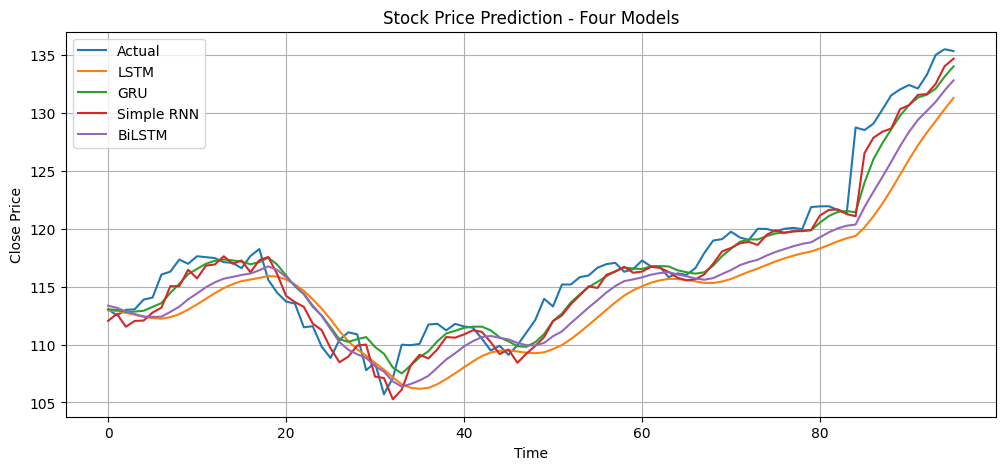

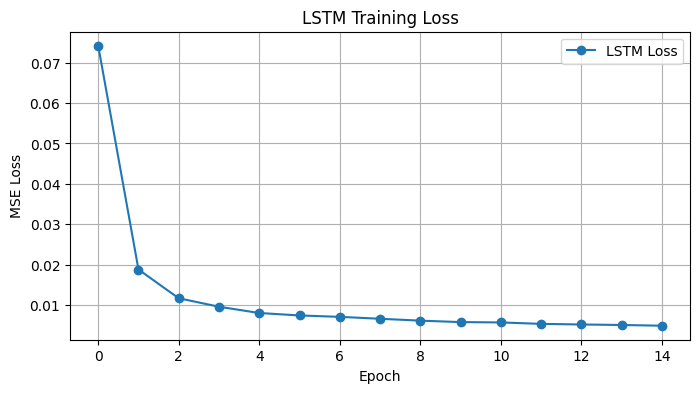

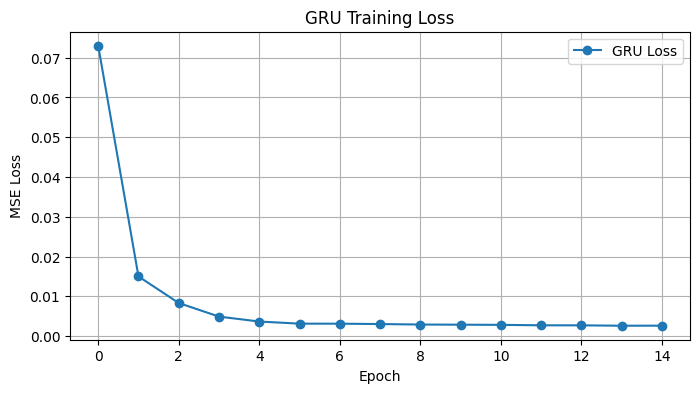

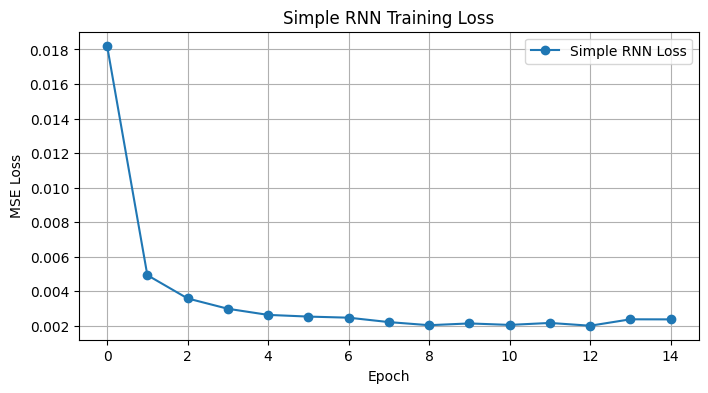

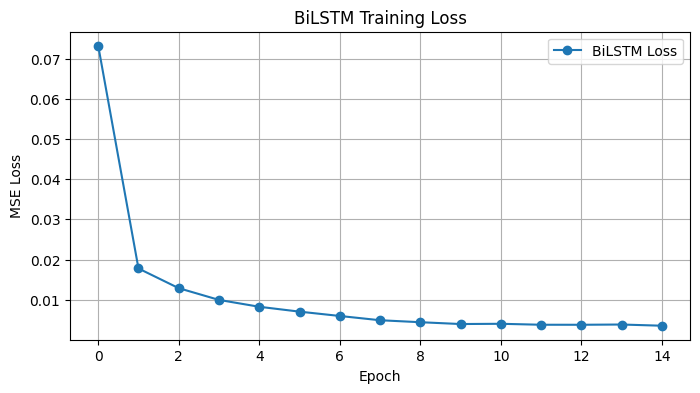

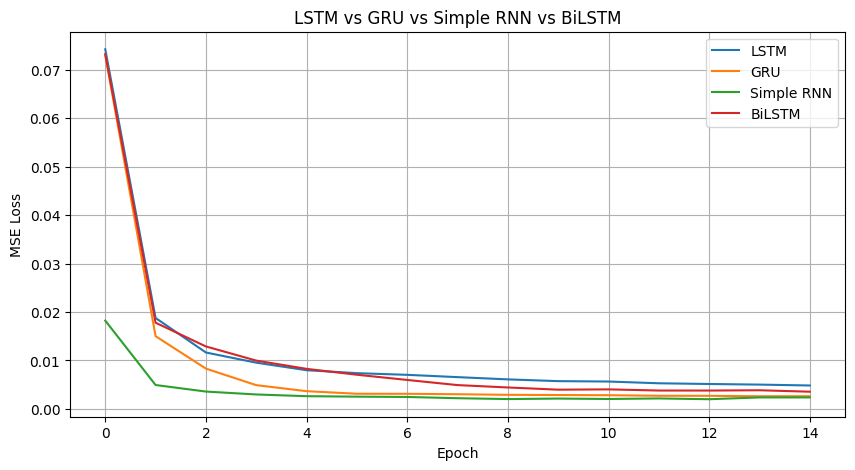


========== TEST METRICS ==========

LSTM
MSE  : 13.379055
MAE  : 3.038270
RMSE : 3.657739

GRU
MSE  : 3.046493
MAE  : 1.311141
RMSE : 1.745421

Simple RNN
MSE  : 2.682960
MAE  : 1.259293
RMSE : 1.637974

BiLSTM
MSE  : 7.531349
MAE  : 2.279483
RMSE : 2.744330

========== TRAINABLE PARAMETERS ==========
LSTM Parameters    : 30,651
GRU Parameters     : 23,301
Simple RNN Params  : 7,701
BiLSTM Parameters  : 81,301

========== FINAL LOSS ==========
LSTM Final Loss   : 0.00483668
GRU Final Loss    : 0.00262404
RNN Final Loss    : 0.00237029
BiLSTM Final Loss : 0.00355422

========== LSTM WEIGHTS ==========

LSTM Weight 1
Shape: (1, 200)
Mean: 0.01387447
Minimum: -0.16601305
Maximum: 0.25739715
Standard Dev: 0.10251737

LSTM Weight 2
Shape: (50, 200)
Mean: 0.00117715
Minimum: -0.26237798
Maximum: 0.26178840
Standard Dev: 0.07199680

LSTM Weight 3
Shape: (200,)
Mean: 0.25385857
Minimum: -0.01570228
Maximum: 1.04163909
Standard Dev: 0.43091431

LSTM Weight 4
Shape: (50, 200)
Mean: 0.00053965
M

In [ ]:
# Q3. Write a python program to predict a stock price from a mastercard stock dataset using LSTM and GRU models.

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt



url = "https://raw.githubusercontent.com/plotly/datasets/master/finance-charts-apple.csv"

df = pd.read_csv(url)

print("\n========== DATASET ==========")

print(df.head())

print(
    "Columns:",
    df.columns.tolist()
)



close = df[
    "AAPL.Close"
].values.astype(
    "float32"
).reshape(-1, 1)

print(
    "\nData Shape:",
    close.shape
)



scaler = MinMaxScaler()

close_scaled = scaler.fit_transform(
    close
)



def make_stock(
    arr,
    n=30
):

    X = []
    y = []

    for i in range(
        len(arr) - n
    ):

        X.append(
            arr[i:i+n]
        )

        y.append(
            arr[i+n]
        )

    return (
        np.array(X),
        np.array(y)
    )


X, y = make_stock(
    close_scaled,
    30
)



split = int(
    len(X) * 0.80
)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]


print("\n========== DATA SPLIT ==========")

print(
    "Total Data:",
    close.shape
)

print(
    "X Train:",
    X_train.shape
)

print(
    "X Test:",
    X_test.shape
)

print(
    "Y Train:",
    y_train.shape
)

print(
    "Y Test:",
    y_test.shape
)



class WeightUpdate(
    tf.keras.callbacks.Callback
):

    def on_train_begin(
        self,
        logs=None
    ):

        self.old = None


    def on_epoch_end(
        self,
        epoch,
        logs=None
    ):

        new = self.model.get_weights()

        print(
            f"\nEpoch {epoch + 1}/15 | "
            f"Loss:{logs['loss']:.6f}"
        )

        for i, w in enumerate(new):

            if self.old is None:

                print(
                    f"W{i + 1} "
                    f"Shape:{w.shape} "
                    f"Mean:{np.mean(w):.6f} "
                    f"Min:{np.min(w):.6f} "
                    f"Max:{np.max(w):.6f} "
                    f"Std:{np.std(w):.6f}"
                )

            else:

                d = (
                    w -
                    self.old[i]
                )

                print(
                    f"W{i + 1} "
                    f"Mean:{np.mean(w):.6f} "
                    f"Min:{np.min(w):.6f} "
                    f"Max:{np.max(w):.6f} "
                    f"Std:{np.std(w):.6f} "
                    f"MeanChange:{np.mean(d):.6f} "
                    f"MaxChange:{np.max(np.abs(d)):.6f}"
                )

        self.old = [
            w.copy()
            for w in new
        ]



lstm_stock = models.Sequential([

    layers.Input(
        shape=(30, 1)
    ),

    layers.LSTM(
        50,
        return_sequences=True
    ),

    layers.LSTM(
        50
    ),

    layers.Dense(
        1
    )
])


print(
    "\n========== LSTM MODEL =========="
)

lstm_stock.summary()


lstm_stock.compile(
    optimizer="adam",
    loss="mse"
)


print(
    "\n========== LSTM TRAINING =========="
)

hist_lstm = lstm_stock.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    verbose=0,
    callbacks=[
        WeightUpdate()
    ]
)



gru_stock = models.Sequential([

    layers.Input(
        shape=(30, 1)
    ),

    layers.GRU(
        50,
        return_sequences=True
    ),

    layers.GRU(
        50
    ),

    layers.Dense(
        1
    )
])


print(
    "\n========== GRU MODEL =========="
)

gru_stock.summary()


gru_stock.compile(
    optimizer="adam",
    loss="mse"
)


print(
    "\n========== GRU TRAINING =========="
)

hist_gru = gru_stock.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    verbose=0,
    callbacks=[
        WeightUpdate()
    ]
)



rnn_stock = models.Sequential([

    layers.Input(
        shape=(30, 1)
    ),

    layers.SimpleRNN(
        50,
        return_sequences=True
    ),

    layers.SimpleRNN(
        50
    ),

    layers.Dense(
        1
    )
])


print(
    "\n========== SIMPLE RNN MODEL =========="
)

rnn_stock.summary()


rnn_stock.compile(
    optimizer="adam",
    loss="mse"
)


print(
    "\n========== SIMPLE RNN TRAINING =========="
)

hist_rnn = rnn_stock.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    verbose=0,
    callbacks=[
        WeightUpdate()
    ]
)



bilstm_stock = models.Sequential([

    layers.Input(
        shape=(30, 1)
    ),

    layers.Bidirectional(
        layers.LSTM(
            50,
            return_sequences=True
        )
    ),

    layers.Bidirectional(
        layers.LSTM(
            50
        )
    ),

    layers.Dense(
        1
    )
])


print(
    "\n========== BILSTM MODEL =========="
)

bilstm_stock.summary()


bilstm_stock.compile(
    optimizer="adam",
    loss="mse"
)


print(
    "\n========== BILSTM TRAINING =========="
)

hist_bilstm = bilstm_stock.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    verbose=0,
    callbacks=[
        WeightUpdate()
    ]
)



print(
    "\n========== PREDICTIONS =========="
)

pred_lstm = lstm_stock.predict(
    X_test,
    verbose=0
)

pred_gru = gru_stock.predict(
    X_test,
    verbose=0
)

pred_rnn = rnn_stock.predict(
    X_test,
    verbose=0
)

pred_bilstm = bilstm_stock.predict(
    X_test,
    verbose=0
)



pred_lstm = scaler.inverse_transform(
    pred_lstm
)

pred_gru = scaler.inverse_transform(
    pred_gru
)

pred_rnn = scaler.inverse_transform(
    pred_rnn
)

pred_bilstm = scaler.inverse_transform(
    pred_bilstm
)

actual = scaler.inverse_transform(
    y_test
)



print(
    "\n========== EPOCH LOSS VALUES =========="
)

for i in range(15):

    print(
        f"Epoch {i + 1:02d}/15 | "
        f"LSTM:{hist_lstm.history['loss'][i]:.6f} | "
        f"GRU:{hist_gru.history['loss'][i]:.6f} | "
        f"RNN:{hist_rnn.history['loss'][i]:.6f} | "
        f"BiLSTM:{hist_bilstm.history['loss'][i]:.6f}"
    )



print(
    "\n========== STOCK PREDICTIONS =========="
)

for i in range(
    len(actual)
):

    print(
        f"Month {i + 1:02d} | "
        f"Actual:{actual[i][0]:.2f} | "
        f"LSTM:{pred_lstm[i][0]:.2f} | "
        f"GRU:{pred_gru[i][0]:.2f} | "
        f"RNN:{pred_rnn[i][0]:.2f} | "
        f"BiLSTM:{pred_bilstm[i][0]:.2f}"
    )



plt.figure(
    figsize=(12, 5)
)

plt.plot(
    actual,
    label="Actual"
)

plt.plot(
    pred_lstm,
    label="LSTM"
)

plt.plot(
    pred_gru,
    label="GRU"
)

plt.plot(
    pred_rnn,
    label="Simple RNN"
)

plt.plot(
    pred_bilstm,
    label="BiLSTM"
)

plt.title(
    "Stock Price Prediction - Four Models"
)

plt.xlabel(
    "Time"
)

plt.ylabel(
    "Close Price"
)

plt.legend()

plt.grid()

plt.show()



plt.figure(
    figsize=(8, 4)
)

plt.plot(
    hist_lstm.history["loss"],
    marker="o",
    label="LSTM Loss"
)

plt.title(
    "LSTM Training Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "MSE Loss"
)

plt.legend()

plt.grid()

plt.show()



plt.figure(
    figsize=(8, 4)
)

plt.plot(
    hist_gru.history["loss"],
    marker="o",
    label="GRU Loss"
)

plt.title(
    "GRU Training Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "MSE Loss"
)

plt.legend()

plt.grid()

plt.show()



plt.figure(
    figsize=(8, 4)
)

plt.plot(
    hist_rnn.history["loss"],
    marker="o",
    label="Simple RNN Loss"
)

plt.title(
    "Simple RNN Training Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "MSE Loss"
)

plt.legend()

plt.grid()

plt.show()



plt.figure(
    figsize=(8, 4)
)

plt.plot(
    hist_bilstm.history["loss"],
    marker="o",
    label="BiLSTM Loss"
)

plt.title(
    "BiLSTM Training Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "MSE Loss"
)

plt.legend()

plt.grid()

plt.show()



plt.figure(
    figsize=(10, 5)
)

plt.plot(
    hist_lstm.history["loss"],
    label="LSTM"
)

plt.plot(
    hist_gru.history["loss"],
    label="GRU"
)

plt.plot(
    hist_rnn.history["loss"],
    label="Simple RNN"
)

plt.plot(
    hist_bilstm.history["loss"],
    label="BiLSTM"
)

plt.title(
    "LSTM vs GRU vs Simple RNN vs BiLSTM"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "MSE Loss"
)

plt.legend()

plt.grid()

plt.show()



lstm_mse = mean_squared_error(
    actual,
    pred_lstm
)

gru_mse = mean_squared_error(
    actual,
    pred_gru
)

rnn_mse = mean_squared_error(
    actual,
    pred_rnn
)

bilstm_mse = mean_squared_error(
    actual,
    pred_bilstm
)


lstm_mae = mean_absolute_error(
    actual,
    pred_lstm
)

gru_mae = mean_absolute_error(
    actual,
    pred_gru
)

rnn_mae = mean_absolute_error(
    actual,
    pred_rnn
)

bilstm_mae = mean_absolute_error(
    actual,
    pred_bilstm
)


lstm_rmse = np.sqrt(
    lstm_mse
)

gru_rmse = np.sqrt(
    gru_mse
)

rnn_rmse = np.sqrt(
    rnn_mse
)

bilstm_rmse = np.sqrt(
    bilstm_mse
)


print(
    "\n========== TEST METRICS =========="
)


print(
    "\nLSTM"
)

print(
    f"MSE  : {lstm_mse:.6f}"
)

print(
    f"MAE  : {lstm_mae:.6f}"
)

print(
    f"RMSE : {lstm_rmse:.6f}"
)


print(
    "\nGRU"
)

print(
    f"MSE  : {gru_mse:.6f}"
)

print(
    f"MAE  : {gru_mae:.6f}"
)

print(
    f"RMSE : {gru_rmse:.6f}"
)


print(
    "\nSimple RNN"
)

print(
    f"MSE  : {rnn_mse:.6f}"
)

print(
    f"MAE  : {rnn_mae:.6f}"
)

print(
    f"RMSE : {rnn_rmse:.6f}"
)


print(
    "\nBiLSTM"
)

print(
    f"MSE  : {bilstm_mse:.6f}"
)

print(
    f"MAE  : {bilstm_mae:.6f}"
)

print(
    f"RMSE : {bilstm_rmse:.6f}"
)



print(
    "\n========== TRAINABLE PARAMETERS =========="
)

print(
    f"LSTM Parameters    : "
    f"{lstm_stock.count_params():,}"
)

print(
    f"GRU Parameters     : "
    f"{gru_stock.count_params():,}"
)

print(
    f"Simple RNN Params  : "
    f"{rnn_stock.count_params():,}"
)

print(
    f"BiLSTM Parameters  : "
    f"{bilstm_stock.count_params():,}"
)



print(
    "\n========== FINAL LOSS =========="
)

print(
    f"LSTM Final Loss   : "
    f"{hist_lstm.history['loss'][-1]:.8f}"
)

print(
    f"GRU Final Loss    : "
    f"{hist_gru.history['loss'][-1]:.8f}"
)

print(
    f"RNN Final Loss    : "
    f"{hist_rnn.history['loss'][-1]:.8f}"
)

print(
    f"BiLSTM Final Loss : "
    f"{hist_bilstm.history['loss'][-1]:.8f}"
)



print(
    "\n========== LSTM WEIGHTS =========="
)

lstm_weights = (
    lstm_stock.get_weights()
)

for i, w in enumerate(
    lstm_weights
):

    print(
        f"\nLSTM Weight {i + 1}"
    )

    print(
        "Shape:",
        w.shape
    )

    print(
        "Mean:",
        f"{np.mean(w):.8f}"
    )

    print(
        "Minimum:",
        f"{np.min(w):.8f}"
    )

    print(
        "Maximum:",
        f"{np.max(w):.8f}"
    )

    print(
        "Standard Dev:",
        f"{np.std(w):.8f}"
    )


print(
    "\n========== GRU WEIGHTS =========="
)

gru_weights = (
    gru_stock.get_weights()
)

for i, w in enumerate(
    gru_weights
):

    print(
        f"\nGRU Weight {i + 1}"
    )

    print(
        "Shape:",
        w.shape
    )

    print(
        "Mean:",
        f"{np.mean(w):.8f}"
    )

    print(
        "Minimum:",
        f"{np.min(w):.8f}"
    )

    print(
        "Maximum:",
        f"{np.max(w):.8f}"
    )

    print(
        "Standard Dev:",
        f"{np.std(w):.8f}"
    )


print(
    "\n========== SIMPLE RNN WEIGHTS =========="
)

rnn_weights = (
    rnn_stock.get_weights()
)

for i, w in enumerate(
    rnn_weights
):

    print(
        f"\nRNN Weight {i + 1}"
    )

    print(
        "Shape:",
        w.shape
    )

    print(
        "Mean:",
        f"{np.mean(w):.8f}"
    )

    print(
        "Minimum:",
        f"{np.min(w):.8f}"
    )

    print(
        "Maximum:",
        f"{np.max(w):.8f}"
    )

    print(
        "Standard Dev:",
        f"{np.std(w):.8f}"
    )


print(
    "\n========== BILSTM WEIGHTS =========="
)

bilstm_weights = (
    bilstm_stock.get_weights()
)

for i, w in enumerate(
    bilstm_weights
):

    print(
        f"\nBiLSTM Weight {i + 1}"
    )

    print(
        "Shape:",
        w.shape
    )

    print(
        "Mean:",
        f"{np.mean(w):.8f}"
    )

    print(
        "Minimum:",
        f"{np.min(w):.8f}"
    )

    print(
        "Maximum:",
        f"{np.max(w):.8f}"
    )

    print(
        "Standard Dev:",
        f"{np.std(w):.8f}"
    )



print(
    "\n========== FIRST 10 PREDICTIONS =========="
)

print(
    f"{'No.':<8}"
    f"{'Actual':<15}"
    f"{'LSTM':<15}"
    f"{'GRU':<15}"
    f"{'RNN':<15}"
    f"{'BiLSTM':<15}"
)


for i in range(
    min(
        10,
        len(actual)
    )
):

    print(
        f"{i + 1:<8}"
        f"{actual[i][0]:<15.2f}"
        f"{pred_lstm[i][0]:<15.2f}"
        f"{pred_gru[i][0]:<15.2f}"
        f"{pred_rnn[i][0]:<15.2f}"
        f"{pred_bilstm[i][0]:<15.2f}"
    )



print(
    "\n"
)

print(
    "=" * 75
)

print(
    "                         SUMMARY"
)

print(
    "=" * 75
)

print(
    f"\nTotal Dataset Samples : "
    f"{len(close)}"
)

print(
    f"Training Samples      : "
    f"{len(X_train)}"
)

print(
    f"Testing Samples       : "
    f"{len(X_test)}"
)

print(
    "Sequence Length       : 30"
)

print(
    "Batch Size            : 32"
)

print(
    "Epochs                : 15"
)


print(
    "\nLSTM:"
)

print(
    f"Final Loss            : "
    f"{hist_lstm.history['loss'][-1]:.8f}"
)

print(
    f"Test MSE              : "
    f"{lstm_mse:.6f}"
)

print(
    f"Test MAE              : "
    f"{lstm_mae:.6f}"
)

print(
    f"Test RMSE             : "
    f"{lstm_rmse:.6f}"
)

print(
    f"Parameters            : "
    f"{lstm_stock.count_params():,}"
)


print(
    "\nGRU:"
)

print(
    f"Final Loss            : "
    f"{hist_gru.history['loss'][-1]:.8f}"
)

print(
    f"Test MSE              : "
    f"{gru_mse:.6f}"
)

print(
    f"Test MAE              : "
    f"{gru_mae:.6f}"
)

print(
    f"Test RMSE             : "
    f"{gru_rmse:.6f}"
)

print(
    f"Parameters            : "
    f"{gru_stock.count_params():,}"
)


print(
    "\nSimple RNN:"
)

print(
    f"Final Loss            : "
    f"{hist_rnn.history['loss'][-1]:.8f}"
)

print(
    f"Test MSE              : "
    f"{rnn_mse:.6f}"
)

print(
    f"Test MAE              : "
    f"{rnn_mae:.6f}"
)

print(
    f"Test RMSE             : "
    f"{rnn_rmse:.6f}"
)

print(
    f"Parameters            : "
    f"{rnn_stock.count_params():,}"
)


print(
    "\nBiLSTM:"
)

print(
    f"Final Loss            : "
    f"{hist_bilstm.history['loss'][-1]:.8f}"
)

print(
    f"Test MSE              : "
    f"{bilstm_mse:.6f}"
)

print(
    f"Test MAE              : "
    f"{bilstm_mae:.6f}"
)

print(
    f"Test RMSE             : "
    f"{bilstm_rmse:.6f}"
)

print(
    f"Parameters            : "
    f"{bilstm_stock.count_params():,}"
)


print(
    "\n"
    + "=" * 75
)

print(
    "                    PROGRAM COMPLETED"
)

print(
    "=" * 75
)


========== INPUT DATA ==========
01. i love machine learning        Label: 1
02. this is a good movie           Label: 1
03. the weather is beautiful       Label: 1
04. i enjoy deep learning          Label: 1
05. this product is excellent      Label: 1
06. the service was amazing        Label: 1
07. i hate this movie              Label: 0
08. this is a bad product          Label: 0
09. the weather is terrible        Label: 0
10. i dislike this service         Label: 0
11. the movie was boring           Label: 0
12. this product is poor           Label: 0
13. machine learning is useful     Label: 1
14. deep learning is powerful      Label: 1
15. the application works well     Label: 1
16. the software is excellent      Label: 1
17. this movie is bad              Label: 0
18. the product is terrible        Label: 0
19. the service is poor            Label: 0
20. the application failed         Label: 0

Input Shape: (20, 6)
Output Shape: (20,)
Vocabulary Size: 33

========== WORD LOOKUP 

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 6, 64)          │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,561 (56.88 KB)

 Trainable params: 14,561 (56.88 KB)

 Non-trainable params: 0 (0.00 B)


========== TRAINING ==========

Epoch 1/20 | Loss:0.693890 | Accuracy:0.625000 | Val Loss:0.710371 | Val Accuracy:0.000000
W1 Shape:(33, 64) Mean:0.000391 Min:-0.053070 Max:0.051776 Std:0.028900
W2 Shape:(64, 128) Mean:0.000334 Min:-0.179213 Max:0.179706 Std:0.102095
W3 Shape:(32, 128) Mean:-0.000339 Min:-0.344920 Max:0.310756 Std:0.088391
W4 Shape:(128,) Mean:0.250025 Min:-0.003726 Max:1.003514 Std:0.433074
W5 Shape:(32, 1) Mean:0.003826 Min:-0.420289 Max:0.376542 Std:0.248220
W6 Shape:(1,) Mean:0.002828 Min:0.002828 Max:0.002828 Std:0.000000

Epoch 2/20 | Loss:0.685567 | Accuracy:0.625000 | Val Loss:0.721824 | Val Accuracy:0.000000
W1 Mean:0.000286 Min:-0.055586 Max:0.053616 Std:0.029085 MeanChange:-0.000106 MaxChange:0.004094
W2 Mean:0.000350 Min:-0.181624 Max:0.182414 Std:0.102111 MeanChange:0.000015 MaxChange:0.003660
W3 Mean:-0.000323 Min:-0.344043 Max:0.309275 Std:0.088414 MeanChange:0.000016 MaxChange:0.003825
W4 Mean:0.250113 Min:-0.005680 Max:1.005210 Std:0.433150 MeanChange

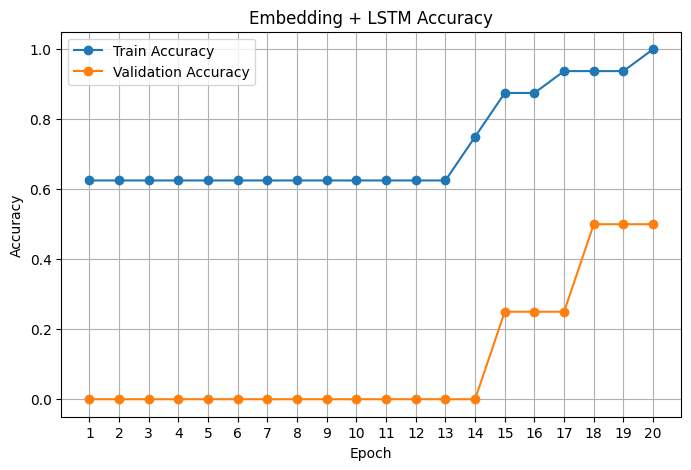

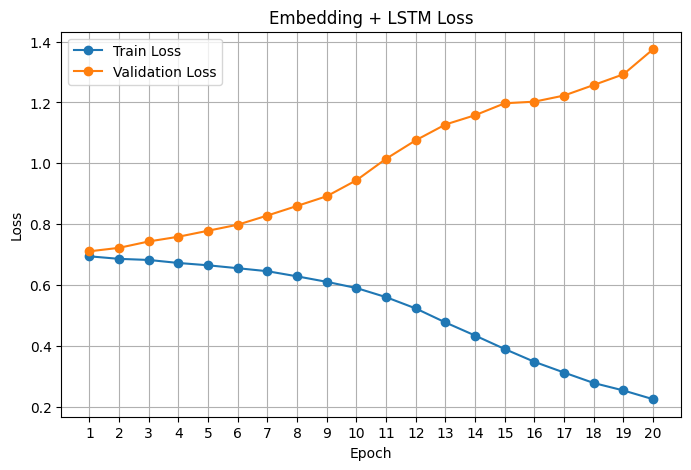


========== USER DEFINED SENTENCE ==========
Enter a sentence: i love my india

Tokens:
['i', 'love', 'my', 'india']

Original Integer Sequence:
[14, 17, 0, 0]

Padded Sequence:
[14, 17, 0, 0, 0, 0]

Probability: 0.9011
Sentiment: Positive

========== FINAL USER RESULT ==========
User Sentence: i love my india
Tokens: ['i', 'love', 'my', 'india']
Sequence: [14, 17, 0, 0, 0, 0]
Probability: 0.9011
Sentiment: Positive


In [ ]:
# Q4. Write a python program to create a sequential model that processes sequences of integers, embeds each integer into a 64-dimensional vector, and then process the sequence of vectors using a LSTM layer.

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt



sentences = [
    "i love machine learning",
    "this is a good movie",
    "the weather is beautiful",
    "i enjoy deep learning",
    "this product is excellent",
    "the service was amazing",
    "i hate this movie",
    "this is a bad product",
    "the weather is terrible",
    "i dislike this service",
    "the movie was boring",
    "this product is poor",
    "machine learning is useful",
    "deep learning is powerful",
    "the application works well",
    "the software is excellent",
    "this movie is bad",
    "the product is terrible",
    "the service is poor",
    "the application failed"
]



y = np.array([
    1, 1, 1, 1, 1, 1,
    0, 0, 0, 0, 0, 0,
    1, 1, 1, 1, 0, 0, 0, 0
])



words = sorted(
    set(
        " ".join(sentences).lower().split()
    )
)


word2idx = {
    word: i + 1
    for i, word in enumerate(words)
}

idx2word = {
    i: word
    for word, i in word2idx.items()
}

vocab_size = len(word2idx) + 1

maxlen = 6



X = []

for sentence in sentences:

    tokens = [
        word2idx.get(
            word,
            0
        )
        for word in sentence.lower().split()
    ]

    tokens = tokens[:maxlen]

    tokens = tokens + [
        0
    ] * (
        maxlen - len(tokens)
    )

    X.append(tokens)


X = np.array(X)



print("\n========== INPUT DATA ==========")

for i in range(len(sentences)):

    print(
        f"{i + 1:02d}. "
        f"{sentences[i]:30s} "
        f"Label: {y[i]}"
    )

print("\nInput Shape:", X.shape)
print("Output Shape:", y.shape)
print("Vocabulary Size:", vocab_size)



print("\n========== WORD LOOKUP TABLE ==========")

for word, index in word2idx.items():

    print(
        f"{word:20s} -> {index}"
    )



seq_model = models.Sequential([

    layers.Input(
        shape=(maxlen,)
    ),

    layers.Embedding(
        input_dim=vocab_size,
        output_dim=64
    ),

    layers.LSTM(
        32
    ),

    layers.Dense(
        1,
        activation="sigmoid"
    )
])



print("\n========== MODEL SUMMARY ==========")

seq_model.summary()



seq_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)



class WeightUpdate(
    tf.keras.callbacks.Callback
):

    def on_train_begin(self, logs=None):

        self.old = None


    def on_epoch_end(
        self,
        epoch,
        logs=None
    ):

        new = self.model.get_weights()

        print(
            f"\nEpoch {epoch + 1}/20 | "
            f"Loss:{logs['loss']:.6f} | "
            f"Accuracy:{logs['accuracy']:.6f} | "
            f"Val Loss:{logs['val_loss']:.6f} | "
            f"Val Accuracy:{logs['val_accuracy']:.6f}"
        )


        for i, w in enumerate(new):

            if self.old is None:

                print(
                    f"W{i + 1} "
                    f"Shape:{w.shape} "
                    f"Mean:{np.mean(w):.6f} "
                    f"Min:{np.min(w):.6f} "
                    f"Max:{np.max(w):.6f} "
                    f"Std:{np.std(w):.6f}"
                )

            else:

                d = w - self.old[i]

                print(
                    f"W{i + 1} "
                    f"Mean:{np.mean(w):.6f} "
                    f"Min:{np.min(w):.6f} "
                    f"Max:{np.max(w):.6f} "
                    f"Std:{np.std(w):.6f} "
                    f"MeanChange:{np.mean(d):.6f} "
                    f"MaxChange:{np.max(np.abs(d)):.6f}"
                )


        self.old = [
            w.copy()
            for w in new
        ]


weight_callback = WeightUpdate()



print("\n========== TRAINING ==========")

hist_seq = seq_model.fit(
    X,
    y,
    epochs=20,
    batch_size=4,
    validation_split=0.2,
    verbose=0,
    callbacks=[
        weight_callback
    ]
)



print("\n========== FINAL RESULTS ==========")

for i in range(20):

    print(
        f"Epoch {i + 1:02d}/20 | "
        f"Loss:{hist_seq.history['loss'][i]:.6f} | "
        f"Accuracy:{hist_seq.history['accuracy'][i]:.6f} | "
        f"Val Loss:{hist_seq.history['val_loss'][i]:.6f} | "
        f"Val Accuracy:{hist_seq.history['val_accuracy'][i]:.6f}"
    )



final_loss = hist_seq.history["loss"][-1]
final_accuracy = hist_seq.history["accuracy"][-1]

final_val_loss = hist_seq.history["val_loss"][-1]
final_val_accuracy = hist_seq.history["val_accuracy"][-1]

print("\n========== LAST EPOCH PERFORMANCE ==========")

print(
    "Training Loss:",
    round(final_loss, 4)
)

print(
    "Training Accuracy:",
    round(final_accuracy * 100, 2),
    "%"
)

print(
    "Validation Loss:",
    round(final_val_loss, 4)
)

print(
    "Validation Accuracy:",
    round(final_val_accuracy * 100, 2),
    "%"
)



print("\n========== PREDICTIONS ==========")

predictions = seq_model.predict(
    X,
    verbose=0
)

for i, p in enumerate(
    predictions
):

    probability = float(
        p[0]
    )

    predicted_class = (
        1
        if probability >= 0.5
        else 0
    )

    sentiment = (
        "Positive"
        if predicted_class == 1
        else "Negative"
    )

    print(
        f"{sentences[i]:30s} | "
        f"Actual:{y[i]} | "
        f"Predicted:{predicted_class} | "
        f"Probability:{probability:.4f} | "
        f"Sentiment:{sentiment}"
    )



plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(1, 21),
    hist_seq.history["accuracy"],
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    range(1, 21),
    hist_seq.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.title(
    "Embedding + LSTM Accuracy"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.xticks(
    range(1, 21)
)

plt.legend()
plt.grid(True)

plt.show()



plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(1, 21),
    hist_seq.history["loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    range(1, 21),
    hist_seq.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title(
    "Embedding + LSTM Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.xticks(
    range(1, 21)
)

plt.legend()
plt.grid(True)

plt.show()



print("\n========== USER DEFINED SENTENCE ==========")

user_sentence = input(
    "Enter a sentence: "
).lower().strip()



user_words = user_sentence.split()

print("\nTokens:")
print(user_words)



user_sequence = []

for word in user_words:

    if word in word2idx:

        user_sequence.append(
            word2idx[word]
        )

    else:

        user_sequence.append(
            0
        )


print("\nOriginal Integer Sequence:")
print(user_sequence)



user_sequence = user_sequence[
    :maxlen
]

user_sequence = (
    user_sequence
    + [0] * (
        maxlen
        - len(user_sequence)
    )
)


user_input = np.array([
    user_sequence
])


print("\nPadded Sequence:")
print(
    user_input[0].tolist()
)



prediction = seq_model.predict(
    user_input,
    verbose=0
)[0][0]

prediction = float(
    prediction
)



if prediction >= 0.5:

    sentiment = "Positive"

else:

    sentiment = "Negative"



print(
    "\nProbability:",
    round(
        prediction,
        4
    )
)

print(
    "Sentiment:",
    sentiment
)


print("\n========== FINAL USER RESULT ==========")

print(
    "User Sentence:",
    user_sentence
)

print(
    "Tokens:",
    user_words
)

print(
    "Sequence:",
    user_input[0].tolist()
)

print(
    "Probability:",
    round(
        prediction,
        4
    )
)

print(
    "Sentiment:",
    sentiment
)